## Step 1: Load Libraries

In [5]:
# Import the necessary libraries/packages
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

## Step 2: Load the filtered dataset

### Step 2a: Explore the filtered results

In [6]:
filter_df = pd.read_parquet('data/filtered_data_roll10mins.parquet')
print(len(filter_df))
print(filter_df.screened.unique())
filtered_df = filter_df[filter_df.screened == True] # if screened is True 
#                                                     it means the filter features were present and the data point passed
print(filtered_df.screened.unique())
filter_df = filter_df[filter_df["screened"]==True]
print(len(filter_df))

2220390
[ True False]
[ True]
1204124


In [7]:
filtered_df.columns
#filtered_df.turbine.unique()

Index(['ts', 'turbine', 'winddir', 'windspeed', 'windvane', 'power', 'nacdir',
       'targetwindvane', 'ti', 'state', 'circ_dif_mean', 'circ_dif_std',
       'ratio_std_comp', 'farm_z_wd', 'screened'],
      dtype='str')

# Step 3: Calculate the consensus predictions

- Including an option to only use the turbines in the first row of the plant (turbine number selection).

Start with the filtered dataset.

We may want to study an option to use a rolling average quantity to predict a rolling average quantity. If the rolling option is desired, first pass the dataset through a rolling average filter, then proceed making sure to denote this additional processing step. 

Write a function that takes in: (1) Output to be predicted (2) Filters out the steered turbines based on a set criteria of valid angles (3) Filter turbines that measure a large yaw to not use these points (4) Which turbine positions are valid to use (5) Which turbine to target (6) Which method to use and (7) Which parameter for the method, if required.

This will need the dataset that contains the distances between the turbines. The methods are farmwise average, Gaussian weighting, and inverse distance weighting (be sure to include the nearest 10 turbines up to all turbines in the park).

The function must output a dataframe with all of the target turbine's measured quantities and filtering features including the measured windvane and the target offset with the addition of the consensus QoI. That way, this dataset can be quickly filtered.

Then the outer loop can be specified: for each method, for each parameter (if applicable), for each turbine in the target set.

We want to report the mean error per turbine, the RMSE per turbine, and the standard deviation of the error itself (or something similar) per turbine for each consensus prediction vs. the measured during the following data slices: (a. steering angle of target less than 0.1, b. steering angle of target greater than 0.1, c. measured windvane of target less than 0.1, d. measured windvane of target greater than 0.1).

Use the method that does the best on the steering angle of target less than 0.1.

### Step 3a: Windvane ()

In [8]:
import consensus2, importlib; importlib.reload(consensus2)
from consensus2 import score_slices, prepare, sweep
locations = pd.read_csv('data/turbines_with_relative_location.csv')
# one-time: pivot long -> wide + build distances
prep = prepare(filtered_df, locations, vane_col='windvane') # DO NOT USE THE NEW CORRECTED windvane
# 1. Do the pivot turbines all have coordinates? (dtype-safe check)
pivot_turbines = prep['turbines']
loc_ids = set(locations['turbine_id'])
missing = [t for t in pivot_turbines if t not in loc_ids]
print("pivot turbines:", pivot_turbines)
print("missing from locations:", missing)

# 2. Are the distances actually NaN for a target? (this is the smoking gun)
print(prep['dist'][403].head(10))
print("all-NaN?", prep['dist'][403].isna().all())

# 3. dtype match between pivot columns and locations ids
print("pivot col dtype:", type(pivot_turbines[0]))
print("locations id dtype:", locations['turbine_id'].dtype)


pivot turbines: [401, 402, 403, 404, 405, 406, 407, 408, 409, 410, 411, 412, 413, 414, 415, 416, 417, 418, 419, 420, 421, 422, 423, 424, 425, 426, 427, 428, 429, 430, 431, 432, 433, 434, 435, 437, 438, 439, 440, 441, 443, 444, 445, 446, 447, 448, 449, 450, 451, 452, 453, 454, 455, 457, 458]
missing from locations: []
401     6.293814
402     2.857976
403     0.000000
404     2.625216
405     5.813021
406     8.598523
407    11.945645
408    14.750240
409    17.530230
410    20.333216
dtype: float64
all-NaN? False
pivot col dtype: <class 'int'>
locations id dtype: int64


In [9]:
# Set the first row
first_row = [401,402,403,404,405,406,407,408,409,410,411,412,413,414,415,416,417,418]
target_turbines = [401, 403, 404, 406,407,408,409,410,411,412]
grid = [('global', [None]),
        ('gaussian', [2,  5, 10, 15,    20]),
        ('invdist', [10, 12, 15, 20, 'all'])]

# dist_offset only affects 'invdist' rows (harmless no-op for global/gaussian). Sweep
# a few candidates -- including 0.0, classic IDW -- so you can see the RMSE / abs_corr /
# ess trade-off directly instead of assuming raw IDW (which favors the nearest turbine)
# is the right choice.
dist_offset_candidates = [0.0]

all_averaged = []
for d0 in dist_offset_candidates:
    _, averaged, _ = sweep(
        prep, qoi='windvane',
        target_turbines=target_turbines,
        method_grid=grid,
        dist_offset=d0,
        valid_turbines=first_row,
        steer_thresh=0.1,
        meas_vane_thresh=None,
        smooth=False,
        smooth_window="10min",
        smooth_gap="5min",
        smooth_min_periods=3,
        smooth_how="mean",
        min_neighbors=1,             # skip a ts if fewer than this many usable neighbors
        selection_slice='e_all',      # unconditioned on vane -- corr/ess aren't vane-specific
        selection_metric='abs_corr',  # unused here (we pick from the combined table below)
        verbose=False,
    )
    averaged = averaged.copy()
    averaged['dist_offset'] = d0
    all_averaged.append(averaged)

averaged_all = pd.concat(all_averaged, ignore_index=True)

# rmse, abs_corr, and ess side by side across every (method, param, dist_offset)
# combination, on the unconditioned slice -- inspect this instead of trusting a
# single RMSE-based "best"
cmp = averaged_all[averaged_all['slice'] == 'e_all'][
    ['method', 'param', 'dist_offset', 'rmse', 'abs_corr', 'ess']
].sort_values('abs_corr')
print(cmp.to_string(index=False))

# pick the winner by LEAST correlation with the target's own signal (abs_corr);
# swap to .sort_values('rmse') above if you'd rather select by RMSE instead
best_row = cmp.iloc[0]
print()
print("selected:", best_row.to_dict())

method = best_row['method']
param = None if best_row['param'] == 'none' else best_row['param']
d0 = best_row['dist_offset']

# winners entries can now be a 3-tuple (method, param, dist_offset); append_consensus
# and estimate_consensus both understand it -- d0 is ignored for non-invdist methods
winners = {'windvane': (method, param, d0)}
# out = append_consensus(corrected_df, prep, winners, target_turbines=first_row,
#                        smooth=True, smooth_gap="5min", smooth_window="10min")

  method param  dist_offset     rmse  abs_corr       ess
  global  none          0.0 5.751471  0.691201 10.732137
gaussian    20          0.0 5.340462  0.730957  9.162931
gaussian    15          0.0 5.186824  0.743844  7.968704
gaussian     2          0.0 5.108893  0.750705  1.440943
gaussian    10          0.0 4.989679  0.757452  5.981927
 invdist   all          0.0 4.921805  0.760908  6.190953
gaussian     5          0.0 4.845642  0.766173  3.119702
 invdist    20          0.0 4.807898  0.771294  5.343844
 invdist    15          0.0 4.752716  0.773572  4.563546
 invdist    12          0.0 4.739751  0.774911  4.202171
 invdist    10          0.0 4.730722  0.776352  3.995882

selected: {'method': 'global', 'param': 'none', 'dist_offset': 0.0, 'rmse': 5.751471215083059, 'abs_corr': 0.6912014443385914, 'ess': 10.732136612756522}


In [10]:
averaged

,method,param,slice,mean_err,rmse,std_err,bias,variance,corr,abs_corr,ess,n_targets,dist_offset
0,gaussian,10,a_targetvane_lt_0.1,-0.009547,4.958879,4.286323,-0.009547,18.705113,0.680220,0.680220,6.236207,10,0.0
1,gaussian,10,b_targetvane_ge_0.1,-1.111394,5.014879,4.293045,-1.111394,18.729380,0.887027,0.887027,3.957611,10,0.0
2,gaussian,10,c_measvane_lt_0.1,0.170427,4.452451,3.662712,0.170427,13.755919,0.025767,0.037260,6.244393,10,0.0
3,gaussian,10,d_measvane_ge_0.1,-0.154094,4.997422,4.321287,-0.154094,18.966443,0.759431,0.759431,5.977875,10,0.0
4,gaussian,10,e_all,-0.149380,4.989679,4.312352,-0.149380,18.889266,0.757452,0.757452,5.981927,10,0.0
5,gaussian,15,a_targetvane_lt_0.1,-0.110059,5.159529,4.421371,-0.110059,19.862020,0.660480,0.660480,8.288268,10,0.0
6,gaussian,15,b_targetvane_ge_0.1,-1.230280,5.206802,4.369905,-1.230280,19.346689,0.882376,0.882376,5.451754,10,0.0
7,gaussian,15,c_measvane_lt_0.1,0.054493,4.647642,3.785083,0.054493,14.675094,0.023310,0.038202,8.325320,10,0.0
8,gaussian,15,d_measvane_ge_0.1,-0.253933,5.194606,4.447720,-0.253933,20.061391,0.745909,0.745909,7.963231,10,0.0
9,gaussian,15,e_all,-0.249480,5.186824,4.438708,-0.249480,19.981383,0.743844,0.743844,7.968704,10,0.0


In [11]:
# a = per_turbine[per_turbine.slice == "a_targetvane_lt_0.1"]
# print(a.groupby("target")["bias"].mean().abs().describe())  # per-turbine |bias| distribution

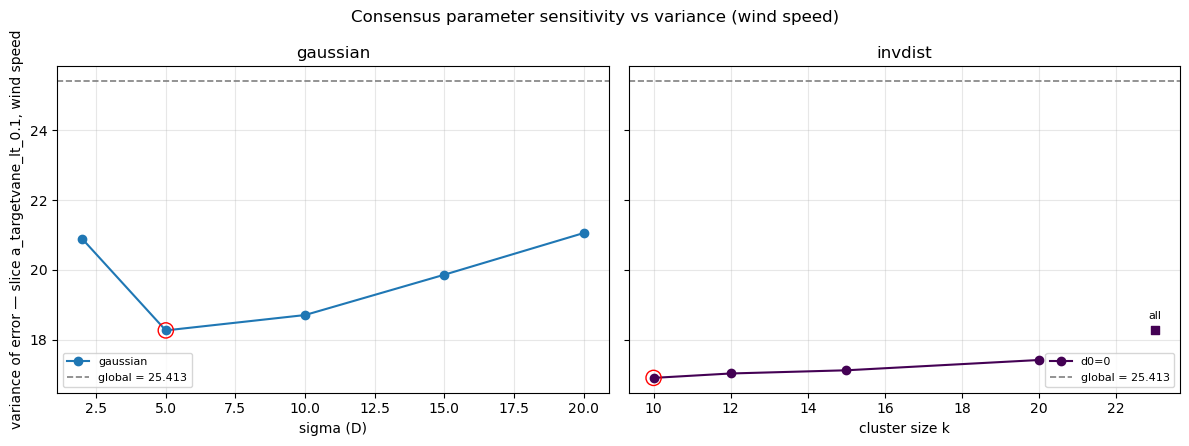

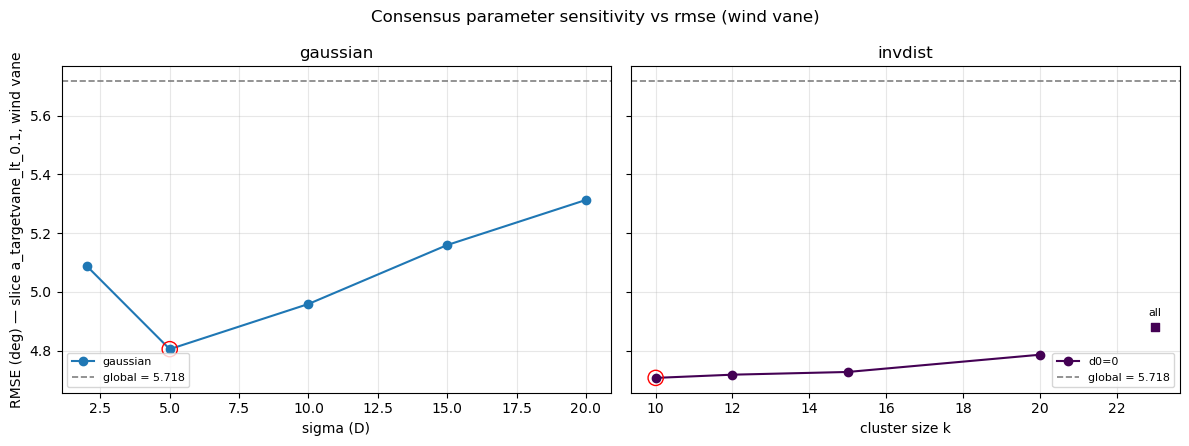

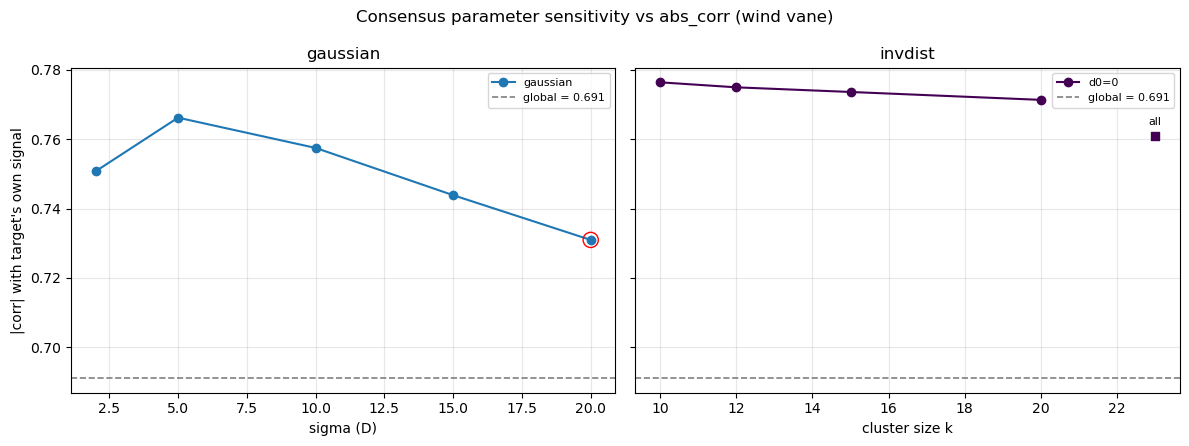

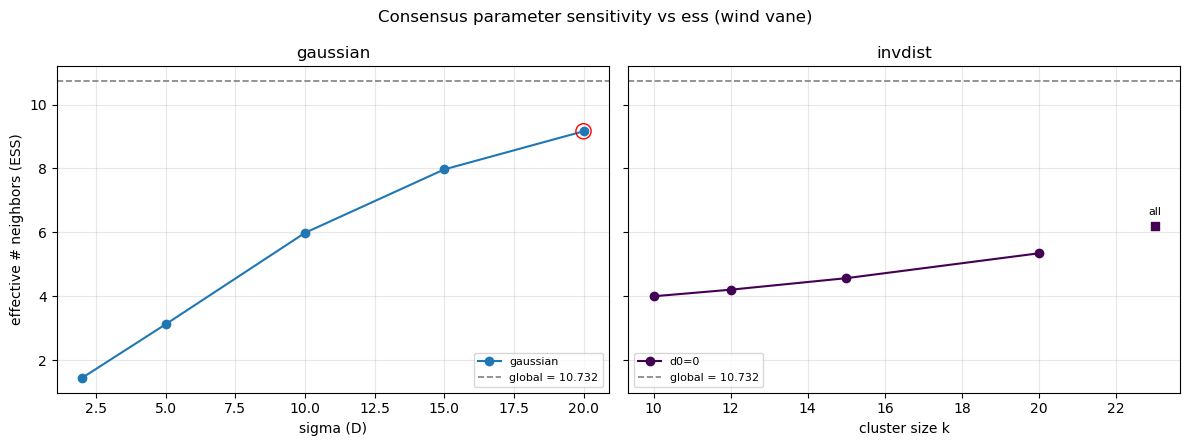

In [12]:
def _to_x(p):
    try:
        return float(p)
    except (ValueError, TypeError):
        return np.nan


def plot_param_vs_metric(averaged, metric, *, slice_name="a_targetvane_lt_0.1",
                          qoi_label="wind vane", ylabel=None, minimize=True):
    """Generalizes the old plot_param_vs_rmse/plot_param_vs_variance to any column
    in `averaged` (e.g. 'rmse', 'variance', 'abs_corr', 'ess'). If `averaged` has a
    'dist_offset' column (present when you concatenate multiple sweep() calls across
    dist_offset candidates -- see the updated sweep cell), invdist gets one line per
    dist_offset value instead of a single curve, so you can see how the offset
    reshapes the k-vs-metric curve. minimize=False marks the max instead of the min
    as "best" -- use that for ess, where higher = more genuine multi-turbine
    averaging (unlike rmse/variance/abs_corr, where lower is better).
    """
    a = averaged[averaged["slice"] == slice_name].copy()
    has_offset = "dist_offset" in a.columns

    g_global = a[a["method"] == "global"]
    global_val = g_global[metric].iloc[0] if len(g_global) else None

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
    cmap = plt.get_cmap("viridis")

    for ax, method in zip(axes, ["gaussian", "invdist"]):
        m = a[a["method"] == method].copy()
        m["x"] = m["param"].map(_to_x)

        # one curve per dist_offset for invdist (gaussian/global are unaffected by
        # dist_offset, so a single curve/line is enough for them)
        offsets = sorted(m["dist_offset"].unique()) if has_offset and method == "invdist" else [None]

        for i, d0 in enumerate(offsets):
            mo = m[m["dist_offset"] == d0] if d0 is not None else m
            finite = mo[mo["x"].notna()].sort_values("x")
            allrow = mo[mo["x"].isna()]              # the 'all' case for invdist

            color = cmap(i / max(len(offsets) - 1, 1)) if d0 is not None else None
            label = method if d0 is None else f"d0={d0:g}"
            ax.plot(finite["x"], finite[metric], marker="o", label=label, color=color)

            if len(mo):
                idx = mo[metric].idxmin() if minimize else mo[metric].idxmax()
                best_row = mo.loc[idx]
                bx = _to_x(best_row["param"])
                if not np.isnan(bx):
                    ax.scatter([bx], [best_row[metric]], s=120, facecolors="none",
                               edgecolors="red", zorder=5)

            if len(allrow):
                xmax = finite["x"].max() if len(finite) else 1
                ax.scatter([xmax * 1.15], [allrow[metric].iloc[0]], marker="s",
                           color=color or "tab:orange", zorder=5)
                ax.annotate("all", (xmax * 1.15, allrow[metric].iloc[0]),
                            textcoords="offset points", xytext=(0, 8), ha="center", fontsize=8)

        if global_val is not None:
            ax.axhline(global_val, color="gray", ls="--", lw=1.2, label=f"global = {global_val:.3f}")

        ax.set_xlabel("sigma (D)" if method == "gaussian" else "cluster size k")
        ax.set_title(method)
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=8)

    axes[0].set_ylabel(ylabel or f"{metric} — slice {slice_name}, {qoi_label}")
    fig.suptitle(f"Consensus parameter sensitivity vs {metric} ({qoi_label})")
    fig.tight_layout()
    plt.show()


# backward-compatible wrappers, same call signatures as before
def plot_param_vs_variance(averaged, slice_name="a_targetvane_lt_0.1", qoi_label="wind speed"):
    plot_param_vs_metric(averaged, "variance", slice_name=slice_name, qoi_label=qoi_label,
                          ylabel=f"variance of error — slice {slice_name}, {qoi_label}")


def plot_param_vs_rmse(averaged, slice_name="a_targetvane_lt_0.1", qoi_label="wind vane"):
    plot_param_vs_metric(averaged, "rmse", slice_name=slice_name, qoi_label=qoi_label,
                          ylabel=f"RMSE (deg) — slice {slice_name}, {qoi_label}")


plot_param_vs_variance(averaged_all, "a_targetvane_lt_0.1")
plot_param_vs_rmse(averaged_all, "a_targetvane_lt_0.1")
plot_param_vs_metric(averaged_all, "abs_corr", slice_name="e_all",
                      ylabel="|corr| with target's own signal")
plot_param_vs_metric(averaged_all, "ess", slice_name="e_all",
                      ylabel="effective # neighbors (ESS)", minimize=False)

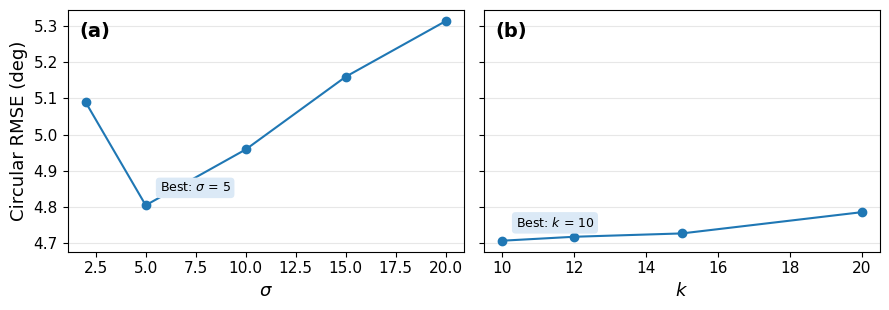

In [13]:

def plot_param_vs_metric_clean(averaged, metric, *, slice_name, ylabel,
                                minimize=True, dist_offset_choice=0):
    """Restyled, simplified version of plot_param_vs_metric:
      - no title / suptitle, no per-panel method title
      - no 'global' reference line, no legend
      - a single curve per panel (for invdist, picks one dist_offset — see
        dist_offset_choice — instead of drawing one line per offset)
      - no 'all' marker
      - theme_bw-style look: horizontal gridlines only, full box border
      - best point annotated inline as "Best: <param> = <value>" in a
        light label box instead of a red circle + legend entry
    """
    a = averaged[averaged["slice"] == slice_name].copy()
    has_offset = "dist_offset" in a.columns
 
    fig, axes = plt.subplots(1, 2, figsize=(9, 3.2), sharey=True)
    xlabels = {"gaussian": r"$\sigma$", "invdist": "$k$"}
    panel_tags = ["(a)", "(b)"]
 
    for ax, method, tag in zip(axes, ["gaussian", "invdist"], panel_tags):
        m = a[a["method"] == method].copy()
        m["x"] = m["param"].map(_to_x)
 
        # collapse invdist down to ONE curve (single dist_offset) instead of
        # one line per offset
        if has_offset and method == "invdist":
            offsets = sorted(m["dist_offset"].unique())
            d0 = dist_offset_choice if dist_offset_choice in offsets else offsets[0]
            m = m[m["dist_offset"] == d0]
 
        finite = m[m["x"].notna()].sort_values("x")
 
        ax.plot(finite["x"], finite[metric], marker="o", color="C0",
                 linewidth=1.5, markersize=6)
 
        idx = finite[metric].idxmin() if minimize else finite[metric].idxmax()
        best_row = finite.loc[idx]
        bx, by = best_row["x"], best_row[metric]
        ax.annotate(
            f"Best: {xlabels[method]} = {bx:g}",
            xy=(bx, by),
            xytext=(10, 10),
            textcoords="offset points",
            fontsize=9,
            bbox=dict(boxstyle="round,pad=0.3", facecolor="#dbe9f6", edgecolor="none"),
        )
 
        ax.set_xlabel(xlabels[method], fontsize=13)
        ax.grid(True, axis="y", alpha=0.3)
        ax.set_axisbelow(True)
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_color("black")
            spine.set_linewidth(0.8)
        ax.tick_params(labelsize=11)
 
        ax.text(0.03, 0.95, tag, transform=ax.transAxes, fontsize=14,
                 fontweight="bold", va="top", ha="left")
 
    for ax in axes:
        ax.label_outer()  # hide y tick labels/label on the right-hand panel
 
    axes[0].set_ylabel(ylabel, fontsize=13)
    fig.tight_layout()
    plt.show()
 
 
def plot_param_vs_circular_rmse(averaged, slice_name="a_targetvane_lt_0.1"):
    plot_param_vs_metric_clean(
        averaged, "rmse",
        slice_name=slice_name,
        ylabel="Circular RMSE (deg)",
    )

plot_param_vs_circular_rmse(averaged_all, "a_targetvane_lt_0.1")

### Step 3b: Windspeed ()

In [14]:
grid = [('global', [None]),
        ('gaussian', [2,  5, 10, 15,    20]),
        ('invdist', [10, 12, 15, 20, 'all'])]

# dist_offset only affects 'invdist' rows (harmless no-op for global/gaussian). Sweep
# a few candidates -- including 0.0, classic IDW -- so you can see the RMSE / abs_corr /
# ess trade-off directly instead of assuming raw IDW (which favors the nearest turbine)
# is the right choice.
dist_offset_candidates = [0.0]

all_averaged = []
for d0 in dist_offset_candidates:
    _, averaged, _ = sweep(
        prep, qoi='windspeed',
        target_turbines=target_turbines,
        method_grid=grid,
        dist_offset=d0,
        valid_turbines=first_row,
        steer_thresh=0.1,
        meas_vane_thresh=None,
        smooth=False,
        smooth_window="10min",
        smooth_gap="5min",
        smooth_min_periods=3,
        smooth_how="mean",
        min_neighbors=1,             # skip a ts if fewer than this many usable neighbors
        selection_slice='e_all',      # unconditioned on vane -- corr/ess aren't vane-specific
        selection_metric='abs_corr',  # unused here (we pick from the combined table below)
        verbose=False,
    )
    averaged = averaged.copy()
    averaged['dist_offset'] = d0
    all_averaged.append(averaged)

averaged_all = pd.concat(all_averaged, ignore_index=True)

# rmse, abs_corr, and ess side by side across every (method, param, dist_offset)
# combination, on the unconditioned slice -- inspect this instead of trusting a
# single RMSE-based "best"
cmp = averaged_all[averaged_all['slice'] == 'e_all'][
    ['method', 'param', 'dist_offset', 'rmse', 'abs_corr', 'ess']
].sort_values('abs_corr')
print(cmp.to_string(index=False))

# pick the winner by LEAST correlation with the target's own signal (abs_corr);
# swap to .sort_values('rmse') above if you'd rather select by RMSE instead
best_row = cmp.iloc[0]
print()
print("selected:", best_row.to_dict())

method = best_row['method']
param = None if best_row['param'] == 'none' else best_row['param']
d0 = best_row['dist_offset']

# winners entries can now be a 3-tuple (method, param, dist_offset); append_consensus
# and estimate_consensus both understand it -- d0 is ignored for non-invdist methods
winners = {'windspeed': (method, param, d0)}
# out = append_consensus(corrected_df, prep, winners, target_turbines=first_row,
#                        smooth=True, smooth_gap="5min", smooth_window="10min")

  method param  dist_offset     rmse  abs_corr       ess
  global  none          0.0 0.924784  0.915119 10.732137
gaussian    20          0.0 0.833421  0.932934  9.162931
gaussian    15          0.0 0.802472  0.938270  7.968704
gaussian     2          0.0 0.802689  0.939217  1.440943
 invdist   all          0.0 0.775574  0.942346  6.190953
gaussian    10          0.0 0.769320  0.943682  5.981927
gaussian     5          0.0 0.757110  0.945815  3.119702
 invdist    20          0.0 0.746894  0.946478  5.343844
 invdist    15          0.0 0.734203  0.947995  4.563546
 invdist    12          0.0 0.728868  0.948665  4.202171
 invdist    10          0.0 0.726534  0.948829  3.995882

selected: {'method': 'global', 'param': 'none', 'dist_offset': 0.0, 'rmse': 0.924784010875334, 'abs_corr': 0.915118643843768, 'ess': 10.732136612756522}


In [15]:
averaged

,method,param,slice,mean_err,rmse,std_err,bias,variance,corr,abs_corr,ess,n_targets,dist_offset
0,gaussian,10,a_targetvane_lt_0.1,-0.027973,0.762201,0.744815,-0.027973,0.562506,0.945752,0.945752,6.236207,10,0.0
1,gaussian,10,b_targetvane_ge_0.1,-0.007202,0.825755,0.804508,-0.007202,0.657095,0.924636,0.924636,3.957611,10,0.0
2,gaussian,10,c_measvane_lt_0.1,-0.142567,0.717075,0.684896,-0.142567,0.488381,0.951246,0.951246,6.244393,10,0.0
3,gaussian,10,d_measvane_ge_0.1,-0.024470,0.769991,0.753340,-0.024470,0.574489,0.943586,0.943586,5.977875,10,0.0
4,gaussian,10,e_all,-0.026304,0.769320,0.752555,-0.026304,0.573449,0.943682,0.943682,5.981927,10,0.0
5,gaussian,15,a_targetvane_lt_0.1,-0.026251,0.796172,0.779035,-0.026251,0.614466,0.940367,0.940367,8.288268,10,0.0
6,gaussian,15,b_targetvane_ge_0.1,-0.012973,0.854909,0.835787,-0.012973,0.707765,0.918511,0.918511,5.451754,10,0.0
7,gaussian,15,c_measvane_lt_0.1,-0.146109,0.752688,0.720456,-0.146109,0.536293,0.945859,0.945859,8.325320,10,0.0
8,gaussian,15,d_measvane_ge_0.1,-0.023625,0.803126,0.786888,-0.023625,0.626054,0.938174,0.938174,7.963231,10,0.0
9,gaussian,15,e_all,-0.025531,0.802472,0.786119,-0.025531,0.624965,0.938270,0.938270,7.968704,10,0.0


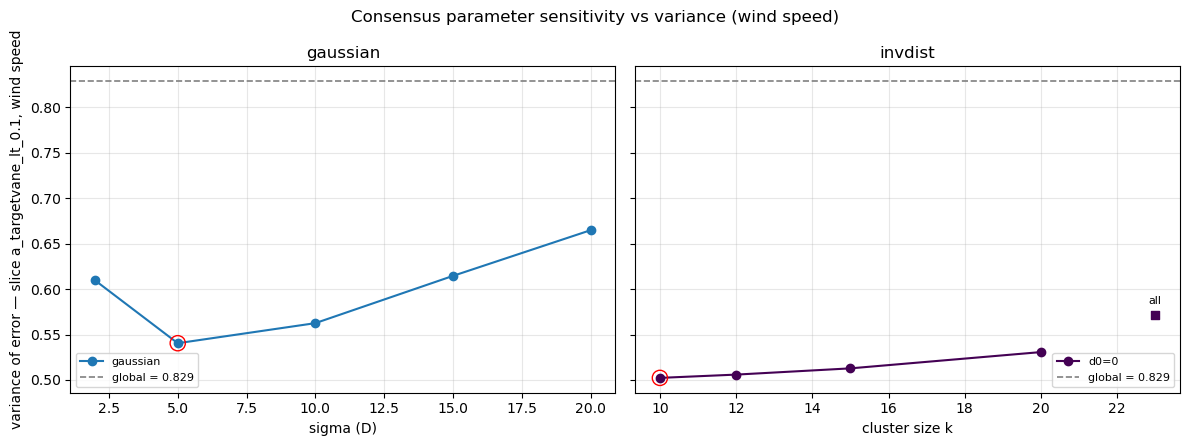

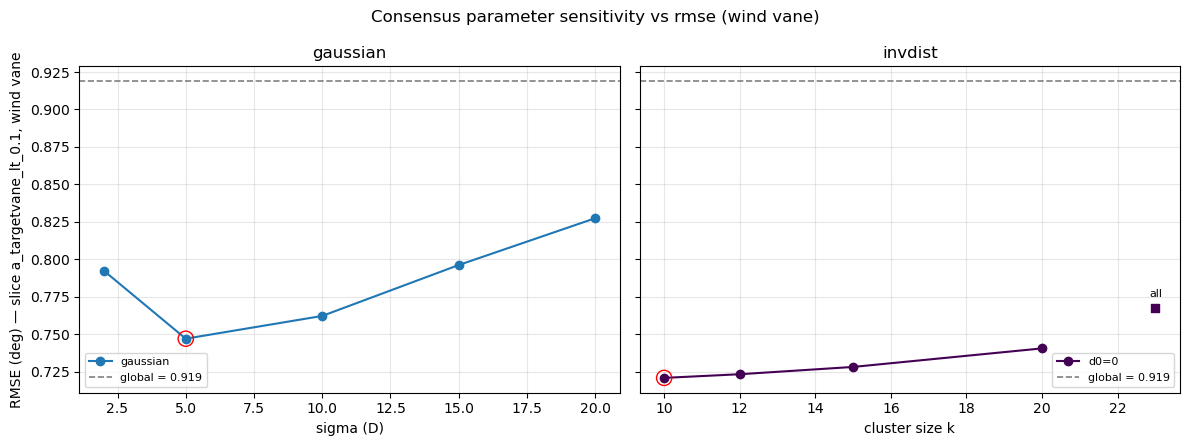

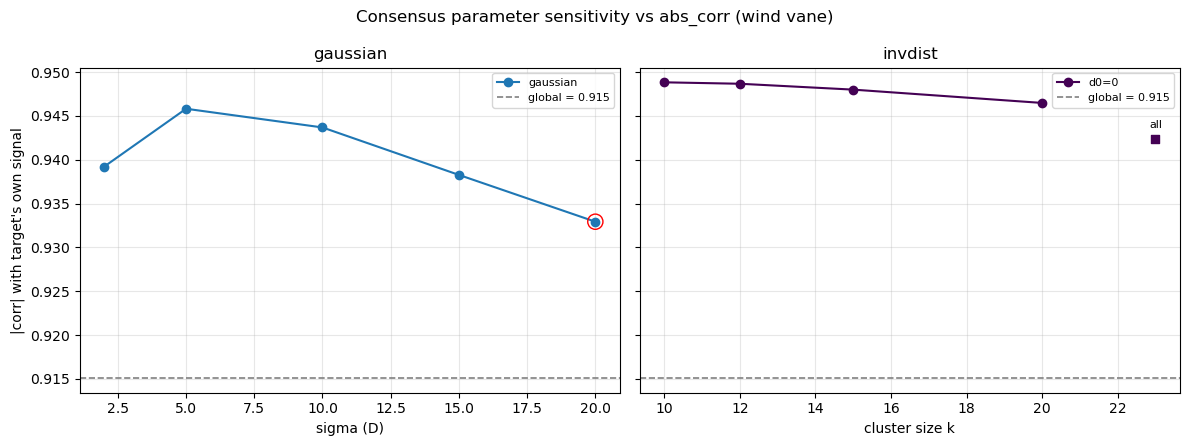

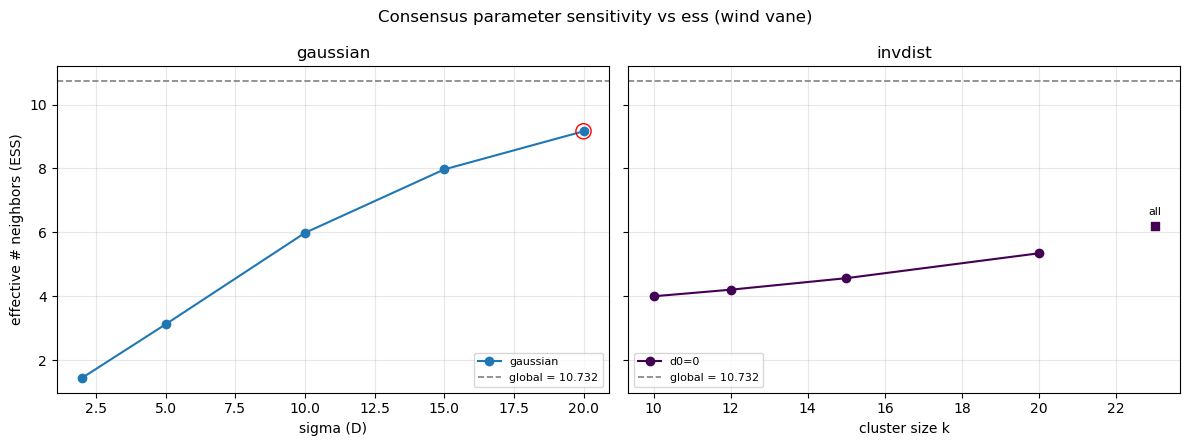

In [16]:
plot_param_vs_variance(averaged_all, "a_targetvane_lt_0.1")
plot_param_vs_rmse(averaged_all, "a_targetvane_lt_0.1")
plot_param_vs_metric(averaged_all, "abs_corr", slice_name="e_all",
                      ylabel="|corr| with target's own signal")
plot_param_vs_metric(averaged_all, "ess", slice_name="e_all",
                      ylabel="effective # neighbors (ESS)", minimize=False)

### Step 3c: Power ()

In [17]:
grid = [('global', [None]),
        ('gaussian', [2,  5, 10, 15,    20]),
        ('invdist', [10, 12, 15, 20, 'all'])]

# dist_offset only affects 'invdist' rows (harmless no-op for global/gaussian). Sweep
# a few candidates -- including 0.0, classic IDW -- so you can see the RMSE / abs_corr /
# ess trade-off directly instead of assuming raw IDW (which favors the nearest turbine)
# is the right choice.
dist_offset_candidates = [0.0]

all_averaged = []
for d0 in dist_offset_candidates:
    _, averaged, _ = sweep(
        prep, qoi='power',
        target_turbines=target_turbines,
        method_grid=grid,
        dist_offset=d0,
        valid_turbines=first_row,
        steer_thresh=0.1,
        meas_vane_thresh=None,
        smooth=False,
        smooth_window="10min",
        smooth_gap="5min",
        smooth_min_periods=3,
        smooth_how="mean",
        min_neighbors=1,             # skip a ts if fewer than this many usable neighbors
        selection_slice='e_all',      # unconditioned on vane -- corr/ess aren't vane-specific
        selection_metric='abs_corr',  # unused here (we pick from the combined table below)
        verbose=False,
    )
    averaged = averaged.copy()
    averaged['dist_offset'] = d0
    all_averaged.append(averaged)

averaged_all = pd.concat(all_averaged, ignore_index=True)

# rmse, abs_corr, and ess side by side across every (method, param, dist_offset)
# combination, on the unconditioned slice -- inspect this instead of trusting a
# single RMSE-based "best"
cmp = averaged_all[averaged_all['slice'] == 'e_all'][
    ['method', 'param', 'dist_offset', 'rmse', 'abs_corr', 'ess']
].sort_values('abs_corr')
print(cmp.to_string(index=False))

# pick the winner by LEAST correlation with the target's own signal (abs_corr);
# swap to .sort_values('rmse') above if you'd rather select by RMSE instead
best_row = cmp.iloc[0]
print()
print("selected:", best_row.to_dict())

method = best_row['method']
param = None if best_row['param'] == 'none' else best_row['param']
d0 = best_row['dist_offset']

# winners entries can now be a 3-tuple (method, param, dist_offset); append_consensus
# and estimate_consensus both understand it -- d0 is ignored for non-invdist methods
winners = {'power': (method, param, d0)}
# out = append_consensus(corrected_df, prep, winners, target_turbines=first_row,
#                        smooth=True, smooth_gap="5min", smooth_window="10min")

  method param  dist_offset       rmse  abs_corr       ess
  global  none          0.0 245.678454  0.920524 10.732137
gaussian     2          0.0 218.872827  0.935574  1.440943
gaussian    20          0.0 219.638050  0.938175  9.162931
gaussian    15          0.0 211.097887  0.943102  7.968704
 invdist   all          0.0 204.514837  0.945947  6.190953
gaussian     5          0.0 201.989692  0.946897  3.119702
gaussian    10          0.0 202.453605  0.947507  5.981927
 invdist    20          0.0 198.648554  0.948920  5.343844
 invdist    15          0.0 196.102685  0.949870  4.563546
 invdist    10          0.0 194.490384  0.950425  3.995882
 invdist    12          0.0 194.762041  0.950484  4.202171

selected: {'method': 'global', 'param': 'none', 'dist_offset': 0.0, 'rmse': 245.6784544412166, 'abs_corr': 0.9205235252395314, 'ess': 10.732136612756522}


In [18]:
averaged

,method,param,slice,mean_err,rmse,std_err,bias,variance,corr,abs_corr,ess,n_targets,dist_offset
0,gaussian,10,a_targetvane_lt_0.1,-20.569962,196.330382,192.852956,-20.569962,38770.781391,0.951429,0.951429,6.236207,10,0.0
1,gaussian,10,b_targetvane_ge_0.1,-27.234734,252.604769,242.377899,-27.234734,64651.751279,0.903240,0.903240,3.957611,10,0.0
2,gaussian,10,c_measvane_lt_0.1,-35.813442,191.693072,186.001948,-35.813442,37217.818535,0.953096,0.953096,6.244393,10,0.0
3,gaussian,10,d_measvane_ge_0.1,-20.162692,202.599939,198.911483,-20.162692,41327.815370,0.947422,0.947422,5.977875,10,0.0
4,gaussian,10,e_all,-20.397806,202.453605,198.744882,-20.397806,41270.352925,0.947507,0.947507,5.981927,10,0.0
5,gaussian,15,a_targetvane_lt_0.1,-20.342678,205.573827,202.353209,-20.342678,42257.914850,0.946863,0.946863,8.288268,10,0.0
6,gaussian,15,b_targetvane_ge_0.1,-28.560774,257.150213,247.769290,-28.560774,66447.869693,0.900718,0.900718,5.451754,10,0.0
7,gaussian,15,c_measvane_lt_0.1,-36.322471,201.804780,196.259124,-36.322471,40696.305477,0.948440,0.948440,8.325320,10,0.0
8,gaussian,15,d_measvane_ge_0.1,-20.224204,211.228201,207.832032,-20.224204,44648.501897,0.943019,0.943019,7.963231,10,0.0
9,gaussian,15,e_all,-20.466757,211.097887,207.678727,-20.466757,44592.369824,0.943102,0.943102,7.968704,10,0.0


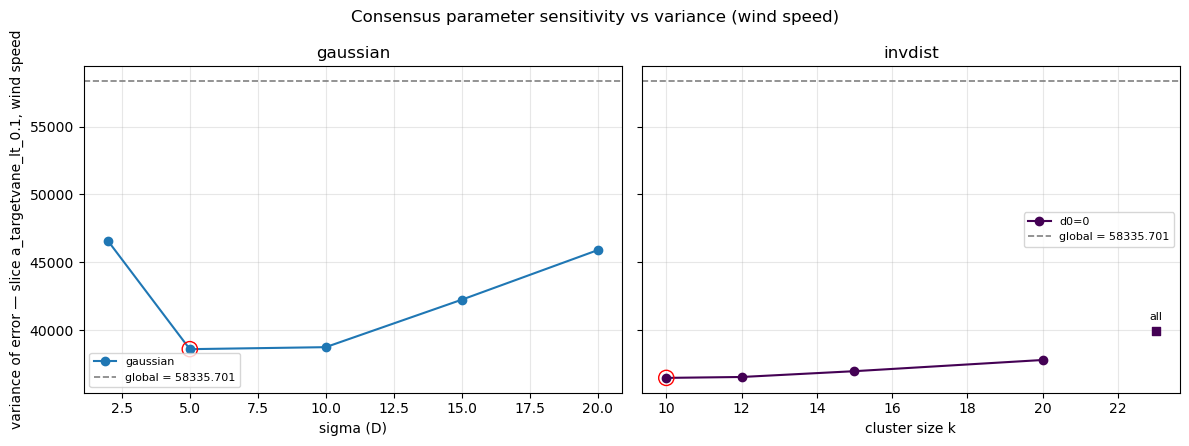

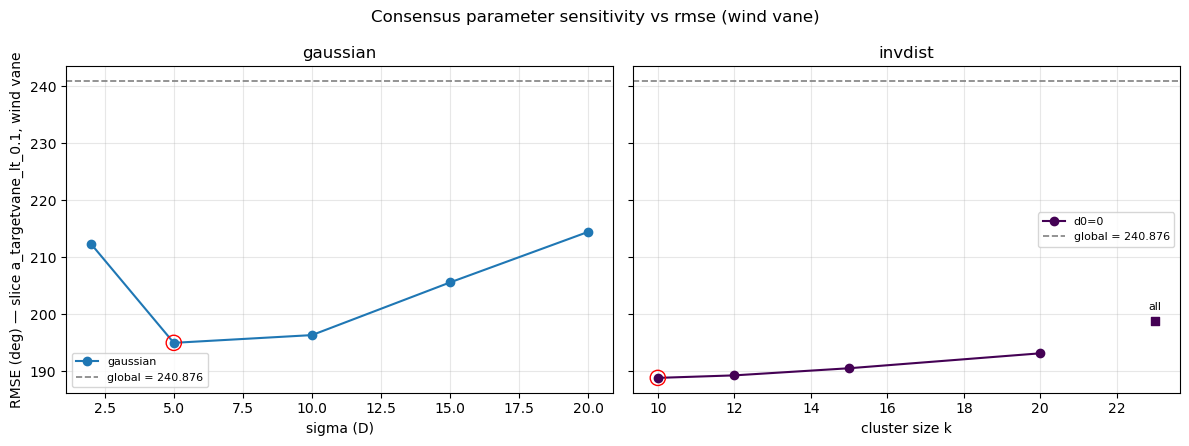

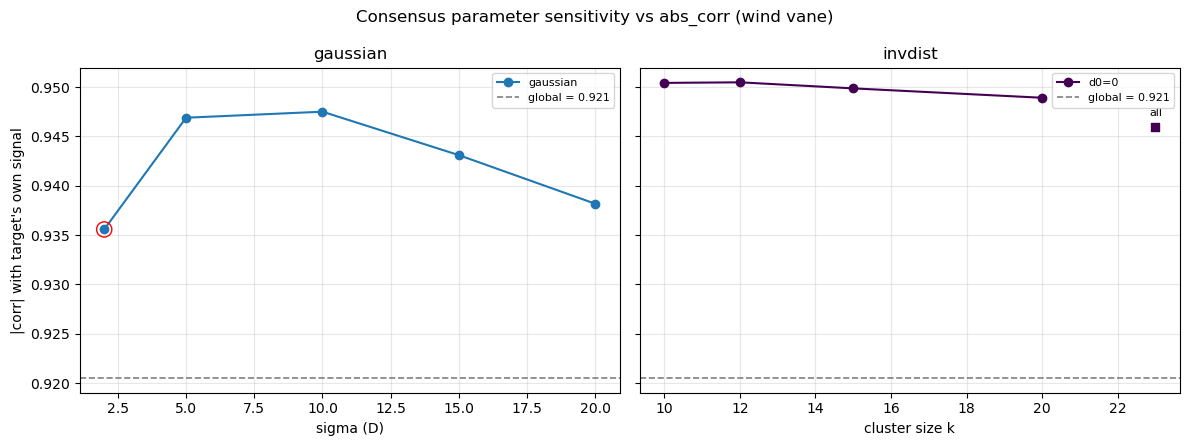

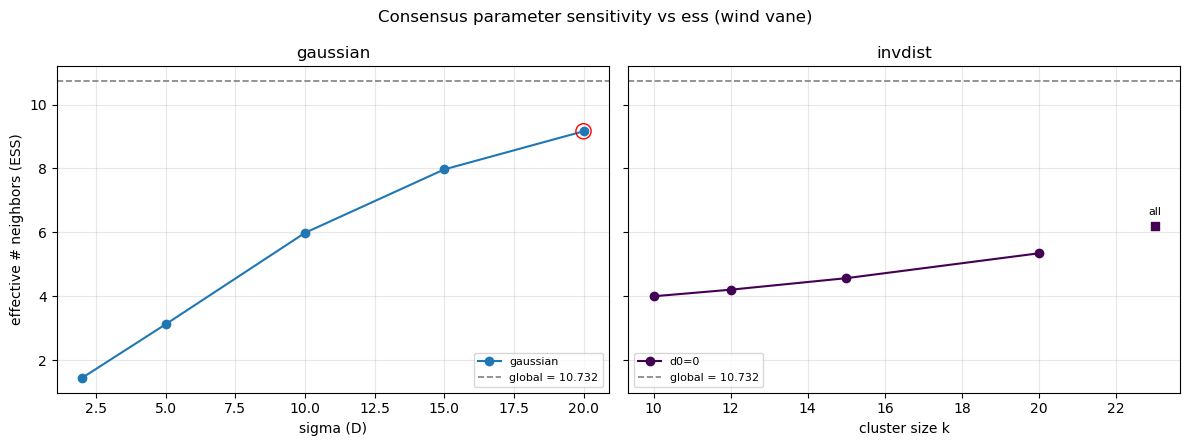

In [19]:
plot_param_vs_variance(averaged_all, "a_targetvane_lt_0.1")
plot_param_vs_rmse(averaged_all, "a_targetvane_lt_0.1")
plot_param_vs_metric(averaged_all, "abs_corr", slice_name="e_all",
                      ylabel="|corr| with target's own signal")
plot_param_vs_metric(averaged_all, "ess", slice_name="e_all",
                      ylabel="effective # neighbors (ESS)", minimize=False)

In [20]:
# p = averaged[(averaged.slice=="a_targetvane_lt_0.1") &
#              (averaged.method.isin(["gaussian","invdist"]))]
# print(p[["method","param","rmse","bias","variance","n_targets"]].sort_values("rmse").to_string(index=False))

# # per-turbine: does invdist k=3 beat gaussian sigma=5 for most turbines, or just on average?
# a = per_turbine[per_turbine.slice=="a_targetvane_lt_0.1"]
# gi = a[(a.method=="invdist")&(a.param=="10")].set_index("target")["rmse"]
# gg = a[(a.method=="gaussian")&(a.param=="5")].set_index("target")["rmse"]
# cmp = pd.DataFrame({"invdist_k3": gi, "gauss_s5": gg})
# cmp["invdist_wins"] = cmp["invdist_k3"] < cmp["gauss_s5"]
# print(cmp.round(1).to_string())
# print("invdist wins on", cmp["invdist_wins"].sum(), "of", len(cmp), "turbines")

## Step 4: Save the best method for each QoI

The inverse distance wins for each, and with a small number of turbines. The variance is the driver to the MSE, the means are all about zero. For all QOI's. Local effects are present. But overall, it is variability that dominates it seems. There is a high amount of relative noise just background in all of the effects. 

Then build a table for each QOI for each turbine in the target list that includes:
- the best method from the consensus methods
- TI
- measured wind vane (and after correction)
- remaining measured predictors
- the turbine number for this data row
 

### Step 4a: Save the combined: 
Consensus is filled only for first_row targets. If your NTF fit only uses first-row turbines, that's exactly right. If you later want consensus for more turbines, just widen target_turbines — the winning method still applies, since it was selected to generalize across the turbine model.

Save format: parquet preserves dtypes and the datetime index cleanly and is much smaller than CSV for a frame this size; use CSV only if you need it human-readable.

In [21]:
winners = {'windvane': ('invdist',10,0),
           'windspeed': ('invdist',10,0),
           'power': ('invdist',10,0)}

In [22]:
from consensus2 import prepare, append_consensus

# set the winners from your three sweeps 

with_consensus = append_consensus(
    filtered_df, prep, winners,
    target_turbines=target_turbines,
    valid_turbines=first_row,
    steer_thresh=0.1,
    meas_vane_thresh=None,
    smooth=False, smooth_gap="5min", smooth_window="10min",smooth_min_periods=3,smooth_how='mean',min_neighbors=1
)

# save
#with_consensus.to_parquet("working_datasets/with_consensus.parquet") 

appended consensus_windvane (invdist, param=10): 216369 non-NaN rows over 10 targets
appended consensus_windspeed (invdist, param=10): 216369 non-NaN rows over 10 targets
appended consensus_power (invdist, param=10): 216369 non-NaN rows over 10 targets
